In [8]:
import sys
sys.path.insert(0, '..')

In [9]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

import pandas as pd
from chainconsumer import ChainConsumer, Chain, Truth


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [10]:
mcmc_df = pd.read_pickle("../batch/gl164-chains.pickle")

mcmc_chain = Chain(samples=mcmc_df, name="MCMC posterior")

plt.figure()
# Plot
c = ChainConsumer()
c.add_chain(mcmc_chain)
fig = c.plotter.plot()

#plt.savefig("gl164-hmc.png")

ValidationError: 1 validation error for Chain
  Assertion failed, Column .params_aberrations_n8o101a1q_0 has NaN or inf in it [type=assertion_error, input_value={'samples':       .params...name': 'MCMC posterior'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/assertion_error

In [ ]:
len(mcmc_df.columns)

64

In [ ]:
separation = mcmc_df[".params_separation"]*42
position_angle = 360-mcmc_df[".params_position_angle"]+np.degrees(np.arctan2(-5.68936e-06,-1.05577e-05))

ps1 = 10**mcmc_df[".params_primary_spectrum_GL164_F108N_0"]
ss1 = 10**mcmc_df[".params_secondary_spectrum_GL164_F108N_0"]
c1 = ps1/ss1
mf1 = (ps1 + ss1)/2

ps2 = 10**mcmc_df[".params_primary_spectrum_GL164_F164N_0"]
ss2 = 10**mcmc_df[".params_secondary_spectrum_GL164_F164N_0"]
c2 = ps2/ss2
mf2 = (ps2 + ss2)/2

ps3 = 10**mcmc_df[".params_primary_spectrum_GL164_F190N_0"]
ss3 = 10**mcmc_df[".params_secondary_spectrum_GL164_F190N_0"]
c3 = ps3/ss3
mf3 = (ps3 + ss3)/2


In [ ]:
plot_df = pd.DataFrame({
    "Separation (mas)": separation, 
    "Position Angle (degrees)": position_angle,
    "F190N Contrast": c3,
    "F164N Contrast": c2,
    "F108N Contrast": c1,
})

<Figure size 460.8x345.6 with 0 Axes>

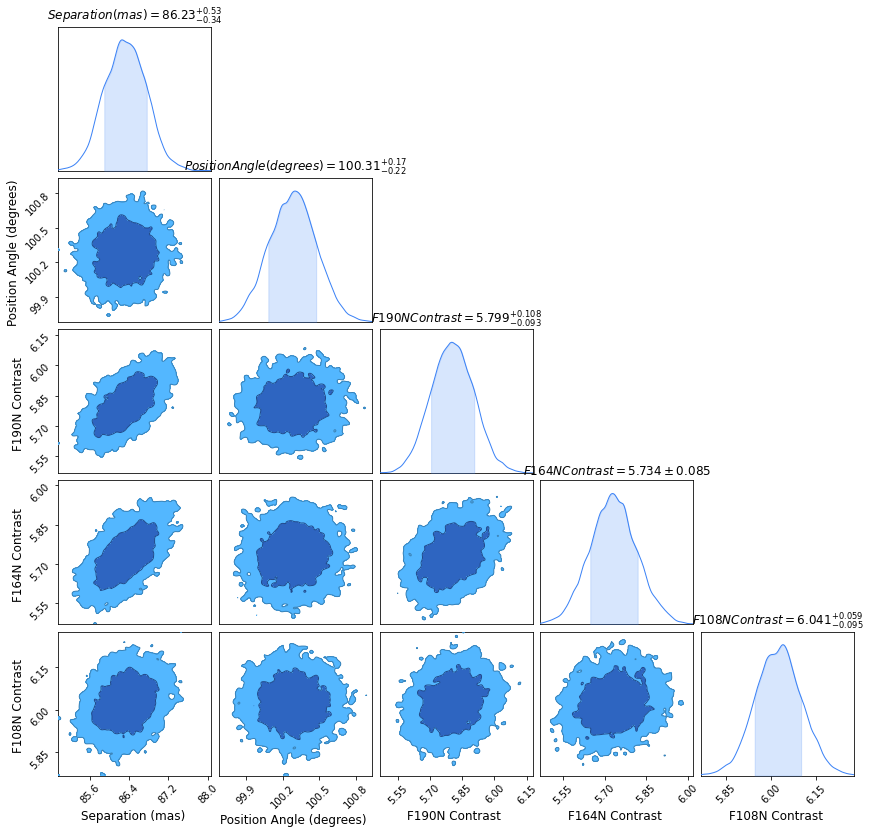

In [ ]:
plot_chain = Chain(samples=plot_df, name="MCMC posterior")

plt.figure()
# Plot
c = ChainConsumer()
c.add_chain(plot_chain)
fig = c.plotter.plot()


In [13]:
10**0.3

1.9952623149688795